In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [30]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [31]:
# Decision tree
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training acc: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing acc: ", accuracy_score(y_test, y_pred_test)*100, "%")
# classic example of overfitting

Training acc:  97.91332263242376 %
Testing acc:  76.86567164179104 %


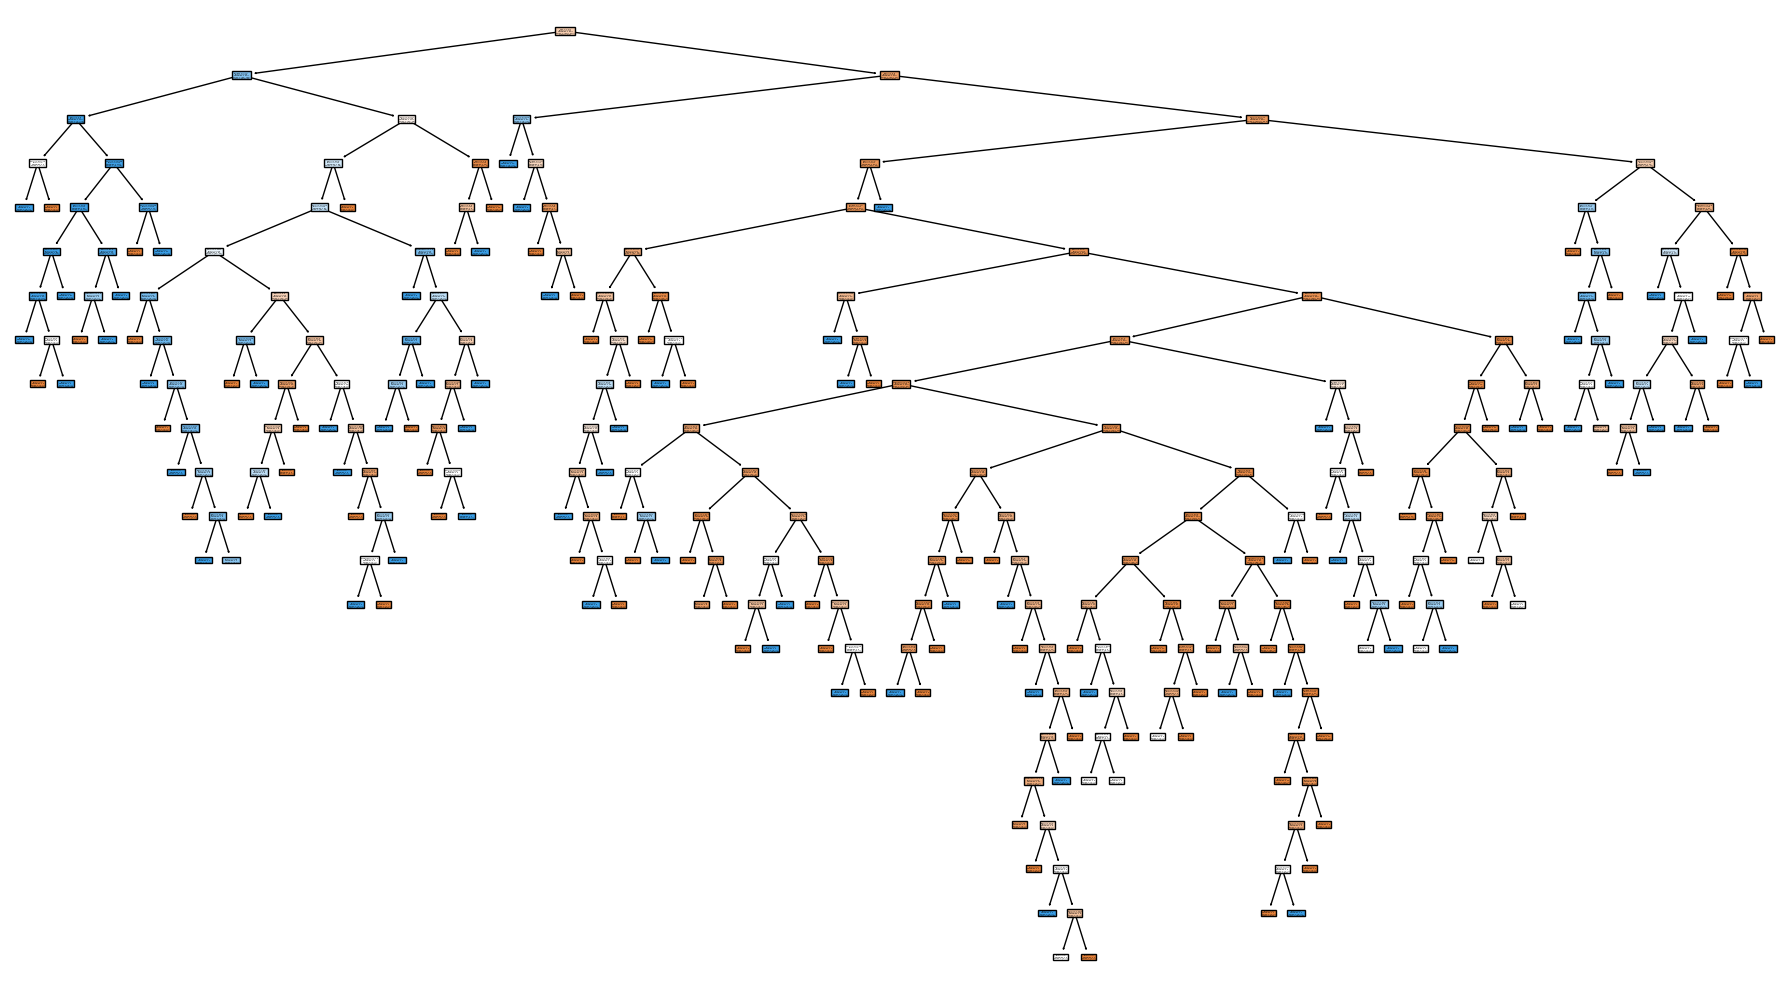

In [32]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Dies","Survived"],
    filled=True
)

plt.tight_layout()

In [33]:
# random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=201,
    oob_score=True
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB score: ", rf.oob_score_)
print("testing acc: ", accuracy_score(y_test, y_pred))

OOB score:  0.8089887640449438
testing acc:  0.7798507462686567


In [35]:
# baggin classifier

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("acc:", accuracy_score(y_test, y_pred))

acc: 0.7761194029850746


In [37]:
# baggin refressor

from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("acc:", accuracy_score(y_test, y_pred))

acc: 0.7947761194029851
